# Ornstein-Uhlenbeck (mean reversion)

The Ornstein-Uhlenbeck process is the canonical *mean-reverting* series: it wanders like a random walk but is continually pulled back toward a long-run level. It models interest-rate spreads, temperatures, and any quantity with an equilibrium it drifts around rather than away from.

::: {.callout-note}
## The model

$$dx_t = \theta\,(\mu - x_t)\,dt + \sigma\,dW_t$$

`theta` is the reversion speed (how hard it is pulled back), `mu` the long-run mean, and `sigma` the volatility. Large `theta` gives a tight band around `mu`; small `theta` approaches a random walk.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import OrnsteinUhlenbeckGenerator

## 1. Reversion speed

`theta` sets how hard the process is pulled back to `mu`. Everything else, including the seed, is held fixed, so the three paths differ only in reversion speed.


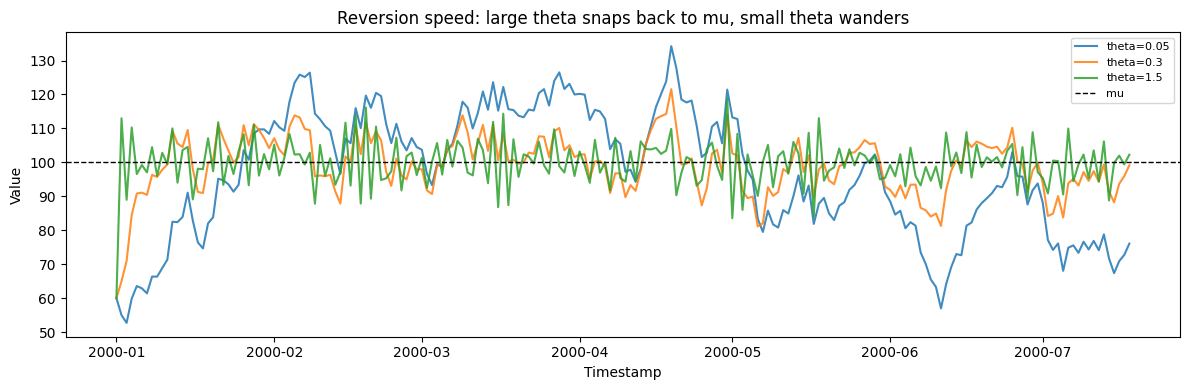

In [ ]:
base = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "mu": 100.0,
    "sigma": 5.0,
    "initial_value": 60.0,
    "seed": 42,
}

fig, ax = plt.subplots(figsize=(12, 4))
for theta in (0.05, 0.3, 1.5):
    df = OrnsteinUhlenbeckGenerator(engine="polars", theta=theta, **base).generate(
        n_series=1
    )
    ax.plot(df["ds"].to_list(), df["y"].to_list(), label=f"theta={theta}", alpha=0.85)
ax.axhline(base["mu"], color="black", linestyle="--", linewidth=1, label="mu")
ax.set(
    xlabel="Timestamp",
    ylabel="Value",
    title="Reversion speed: large theta snaps back to mu, small theta wanders",
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 2. Volatility

`sigma` sets the size of the random shocks. With `theta` fixed, a larger `sigma` widens the band the process occupies around `mu` without changing how fast it returns.


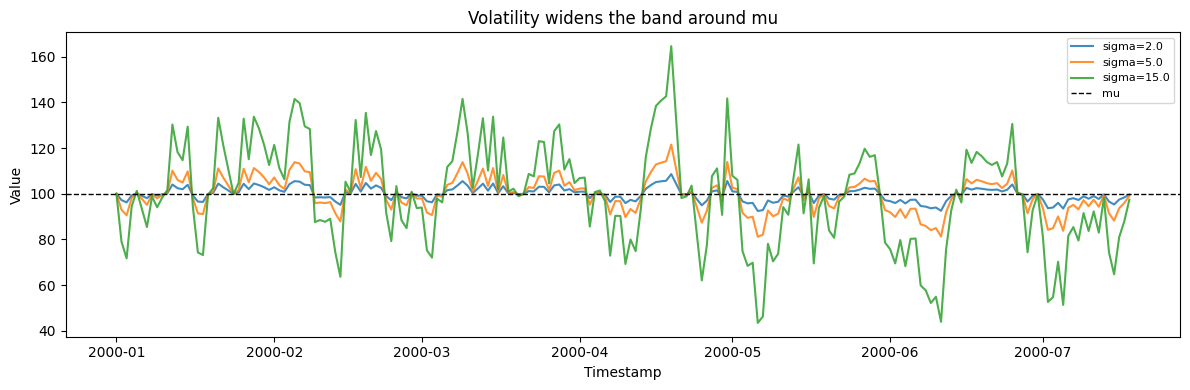

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for sigma in (2.0, 5.0, 15.0):
    df = OrnsteinUhlenbeckGenerator(
        engine="polars",
        min_length=200,
        max_length=200,
        freq="D",
        theta=0.3,
        mu=100.0,
        sigma=sigma,
        initial_value=100.0,
        seed=42,
    ).generate(n_series=1)
    ax.plot(df["ds"].to_list(), df["y"].to_list(), label=f"sigma={sigma}", alpha=0.85)
ax.axhline(100.0, color="black", linestyle="--", linewidth=1, label="mu")
ax.set(xlabel="Timestamp", ylabel="Value", title="Volatility widens the band around mu")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Multiple series

Generate multiple independent OU processes in one call.

In [ ]:
multi_params = {
    "min_length": 150,
    "max_length": 150,
    "freq": "D",
    "theta": 0.5,
    "mu": 100.0,
    "sigma": 5.0,
    "initial_value": 80.0,
    "seed": 42,
}

multi_gen = OrnsteinUhlenbeckGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=3)

print(f"Generated 3 series with {len(multi_df)} total observations")
print(f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, Std={multi_df['y'].std():.4f}")
multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 3 series with 450 total observations
Overall Statistics: Mean=99.8925, Std=5.8501


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,80.0
"""0""",2000-01-02 00:00:00,82.992031
"""0""",2000-01-03 00:00:00,86.966288
"""0""",2000-01-04 00:00:00,98.258423
"""0""",2000-01-05 00:00:00,100.832489
"""0""",2000-01-06 00:00:00,97.918522
"""0""",2000-01-07 00:00:00,95.635111
"""0""",2000-01-08 00:00:00,100.825374
"""0""",2000-01-09 00:00:00,98.708297


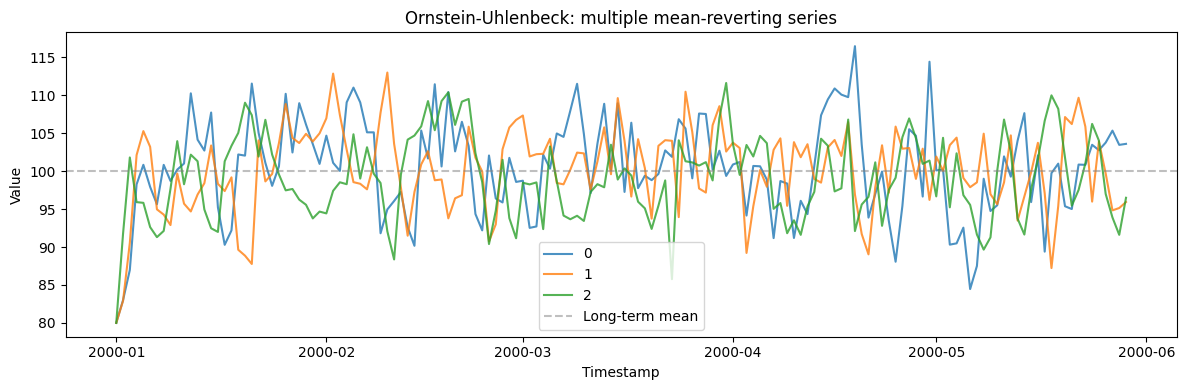

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.axhline(y=100.0, color="gray", linestyle="--", alpha=0.5, label="Long-term mean")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Ornstein-Uhlenbeck: multiple mean-reverting series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Random walk](/synforecast/docs/generators/statistical/random_walk.html) — the no-reversion limit (`theta` → 0).
- [Bounded process](/synforecast/docs/generators/stochastic/bounded_process.html) — mean reversion constrained to an interval.

Reversion, mean, and volatility parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::